Author : Masayu Anandita Prameswari

Notes : This project was developed with the assistance of AI tools for code structuring and ideation.
All modeling decisions, validation, interpretation, and business insights were independently reviewed and implemented by me.

---

## Executive Summary

This notebook addresses two business questions:

| Section | Question | Methods |
|---------|----------|---------|
| **A. Demand Forecast** | Predict revenue for the next 6 months & identify products to stock up | Prophet, SARIMA, XGBoost |
| **B. Customer 360** | Identify high-value customers and predict churn risk | CLV scoring, Logistic Regression, Random Forest |

---

# Part A — Demand Forecast

## 1. Setup & Imports

In [34]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})


## 2. Load & Preview Data

In [35]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [36]:
df=pd.read_csv('/content/drive/MyDrive/Data/retail_transaction_data.csv')
df

,order_id,product_id,product_description,quantity,order_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## 3. Data Cleaning

**Steps performed:**
1. Flag and separate cancelled orders (order_id starts with "C")
2. Remove duplicate rows
3. Fill missing product descriptions with product_id as placeholder
4. Drop rows with quantity ≤ 0 or unit_price ≤ 0 (invalid / return noise)
5. Parse dates; engineer `revenue`, `year`, `month`, `year_month`

In [37]:
#3.a  Separate cancelled orders ────────────────────────────────────────
df["is_cancelled"] = df["order_id"].astype(str).str.startswith("C")
cancelled_df = df[df["is_cancelled"]].copy()
df_clean     = df[~df["is_cancelled"]].copy()

#3.b  Remove duplicates ─────────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean):,}")

#3.c  Patch missing product descriptions ────────────────────────────────
df_clean["product_description"] = df_clean["product_description"].fillna(
    df_clean["product_id"].astype(str)
)

#3.d  Remove invalid transactions ──────────────────────────────────────
df_clean = df_clean[(df_clean["quantity"] > 0) & (df_clean["unit_price"] > 0)].copy()

#3.e  Date & feature engineering ───────────────────────────────────────
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])
df_clean["revenue"]    = df_clean["quantity"] * df_clean["unit_price"]
df_clean["year"]       = df_clean["order_date"].dt.year
df_clean["month"]      = df_clean["order_date"].dt.month
df_clean["year_month"] = df_clean["order_date"].dt.to_period("M")

#Working datasets ───────────────────────────────────────────────────────
df_revenue   = df_clean.copy()
df_customers = df_clean.dropna(subset=["customer_id"]).copy()

print(f"\nClean dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"Date range   : {df_clean['order_date'].min().date()} → {df_clean['order_date'].max().date()}")


Duplicates removed: 33,945

Clean dataset: 1,007,913 rows, 13 columns
Date range   : 2009-12-01 → 2011-12-09


## 4. Key Business Metrics

In [38]:
total_revenue      = df_clean["revenue"].sum()
total_orders       = df_clean["order_id"].nunique()
total_customers    = df_clean["customer_id"].nunique()
total_products     = df_clean["product_id"].nunique()
cancellation_rate  = len(cancelled_df) / len(df) * 100
avg_order_value    = total_revenue / total_orders

metrics = {
    "Total Revenue ($)"    : f"{total_revenue:,.2f}",
    "Total Orders"         : f"{total_orders:,}",
    "Unique Customers"     : f"{total_customers:,}",
    "Unique Products"      : f"{total_products:,}",
    "Cancellation Rate (%)" : f"{cancellation_rate:.1f}",
    "Avg Order Value ($)"  : f"{avg_order_value:,.2f}",
}

print("=" * 45)
print("  KEY BUSINESS METRICS")
print("=" * 45)
for k, v in metrics.items():
    print(f"  {k:<26}: {v:>12}")


  KEY BUSINESS METRICS
  Total Revenue ($)         : 20,476,260.45
  Total Orders              :       40,077
  Unique Customers          :        5,878
  Unique Products           :        4,917
  Cancellation Rate (%)     :          1.8
  Avg Order Value ($)       :       510.92


## 5. Exploratory Data Analysis

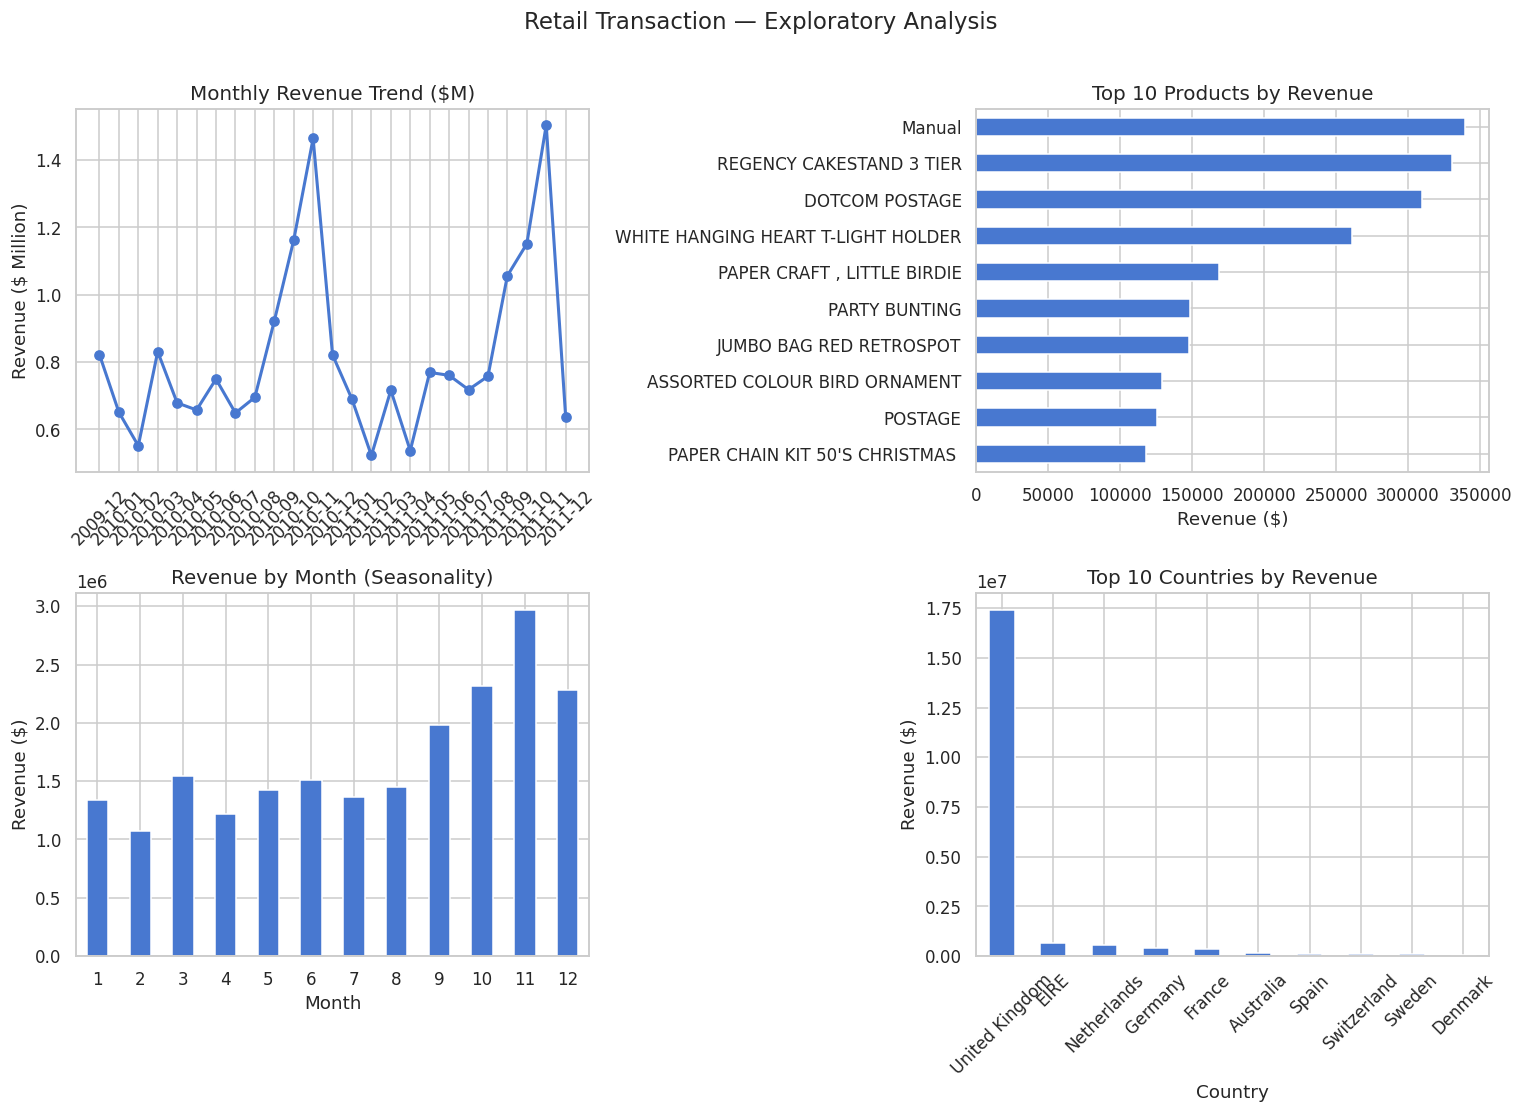

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Retail Transaction — Exploratory Analysis", fontsize=15, y=1.01)

#Monthly Revenue Trend ─────────────────────────────────────────────────
ax = axes[0, 0]
monthly = df_clean.groupby("year_month")["revenue"].sum().reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)
ax.plot(monthly["year_month"], monthly["revenue"] / 1e6, marker="o", linewidth=2)
ax.set_title("Monthly Revenue Trend ($M)")
ax.set_xlabel("")
ax.set_ylabel("Revenue ($ Million)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True)

#Top 10 Products by Revenue ────────────────────────────────────────────
ax = axes[0, 1]
top_products = (
    df_clean.groupby("product_description")["revenue"]
    .sum().sort_values(ascending=False).head(10).sort_values()
)
top_products.plot(kind="barh", ax=ax)
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("")

#Revenue by Month (Seasonality) ────────────────────────────────────────
ax = axes[1, 0]
month_rev = df_clean.groupby("month")["revenue"].sum()
month_rev.plot(kind="bar", ax=ax)
ax.set_title("Revenue by Month (Seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=0)

#Top 10 Countries by Revenue ───────────────────────────────────────────
ax = axes[1, 1]
country_rev = (
    df_clean.groupby("country")["revenue"]
    .sum().sort_values(ascending=False).head(10)
)
country_rev.plot(kind="bar", ax=ax)
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Country")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


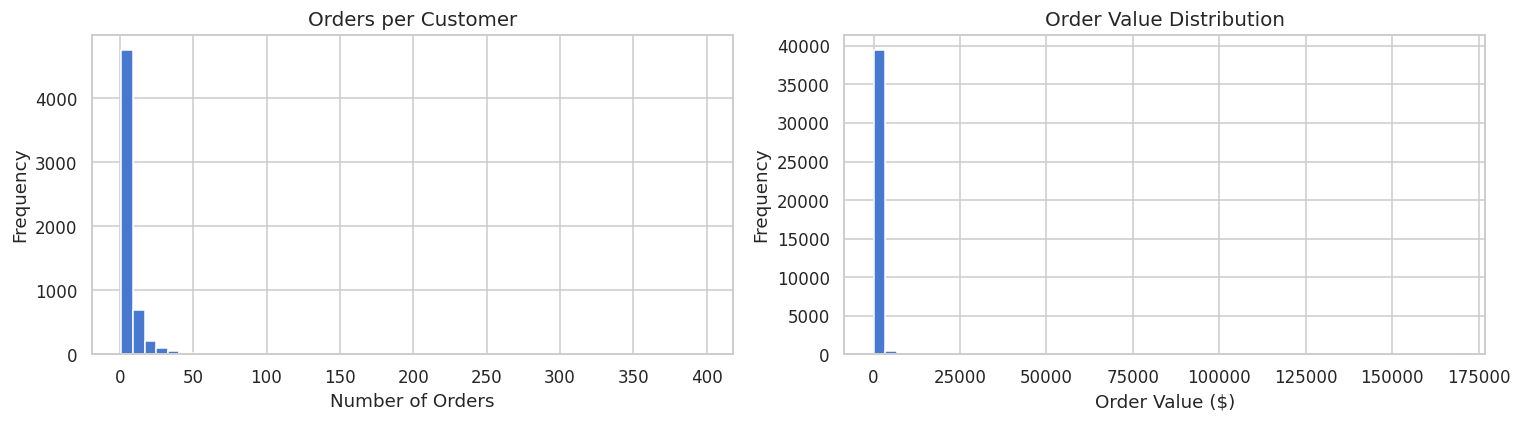

Median orders / customer: 3
Median order value      : $302.22


In [40]:
# Order distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

orders_per_customer = df_clean.groupby("customer_id")["order_id"].nunique()
axes[0].hist(orders_per_customer, bins=50)
axes[0].set_title("Orders per Customer")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Frequency")

order_value = df_clean.groupby("order_id")["revenue"].sum()
axes[1].hist(order_value, bins=50)
axes[1].set_title("Order Value Distribution")
axes[1].set_xlabel("Order Value ($)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Median orders / customer: {orders_per_customer.median():.0f}")
print(f"Median order value      : ${order_value.median():,.2f}")


## 6. RFM Customer Segmentation

Used to understand the customer base before forecasting and to feed the Customer 360 model.

| Score | Meaning |
|-------|---------|
| **R** (Recency) | Days since last purchase — lower = more recent = score 4 |
| **F** (Frequency) | Number of distinct orders — higher = score 4 |
| **M** (Monetary) | Total spend — higher = score 4 |


RFM Segment Distribution:
segment
Champions              1740
Needs Attention        1591
Potential Loyalists    1216
Loyal Customers        1186
New Customers           137
At Risk                   8


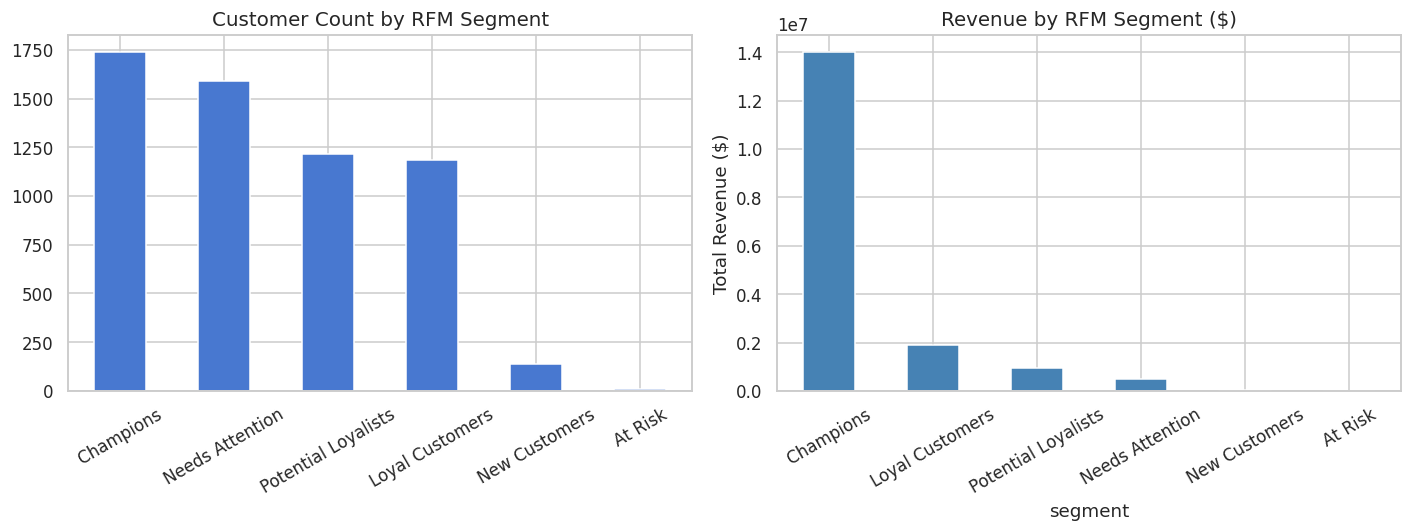

In [41]:
snapshot_date = df_clean["order_date"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("customer_id").agg(
    recency   = ("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency = ("order_id",   "nunique"),
    monetary  = ("revenue",    "sum"),
).reset_index()

# Score 1–4 (4 = best)
rfm["r_score"] = pd.qcut(rfm["recency"],   4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"],  4, labels=[1,2,3,4]).astype(int)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

def segment(row):
    if row["rfm_score"] >= 10:              return "Champions"
    elif row["rfm_score"] >= 8:             return "Loyal Customers"
    elif row["rfm_score"] >= 6:             return "Potential Loyalists"
    elif row["r_score"] >= 3 and row["f_score"] <= 2: return "New Customers"
    elif row["r_score"] <= 2 and row["f_score"] >= 3: return "At Risk"
    else:                                   return "Needs Attention"

rfm["segment"] = rfm.apply(segment, axis=1)

seg_counts = rfm["segment"].value_counts()
print("RFM Segment Distribution:")
print(seg_counts.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Customer Count by RFM Segment")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

seg_revenue = rfm.merge(rfm[["customer_id"]], on="customer_id").copy()
# monetary already computed in rfm
rfm_revenue = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=False)
rfm_revenue.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Revenue by RFM Segment ($)")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 7. Demand Forecasting

### Approach
Compare **three models** on a held-out 3-month test set:

| Model | Strength | Weakness |
|-------|----------|----------|
| **Prophet** | Handles seasonality & holidays automatically; interpretable | Requires sufficient history; can over-fit changepoints |
| **SARIMA(1,1,1)(1,1,0,12)** | Classic, well-understood; good for stationary series | Needs manual parameter tuning; struggles with complex seasonality |
| **XGBoost + Lag Features** | Flexible; captures non-linear patterns | Needs careful feature engineering; doesn't natively extrapolate |

### Evaluation Metrics
- **MAE** — Mean Absolute Error (in $)
- **RMSE** — Root Mean Squared Error (penalises large errors more)
- **MAPE** — Mean Absolute Percentage Error (scale-free; primary ranking metric)


In [42]:
#Build monthly time series ──────────────────────────────────────────────
monthly_ts = (
    df_clean.groupby(df_clean["order_date"].dt.to_period("M"))["revenue"]
    .sum().reset_index()
)
monthly_ts.columns = ["period", "revenue"]
monthly_ts["ds"] = monthly_ts["period"].dt.to_timestamp()
monthly_ts = monthly_ts.sort_values("ds").reset_index(drop=True)
monthly_ts["y"] = monthly_ts["revenue"]

print(f"Time series length: {len(monthly_ts)} months")
print(monthly_ts[["ds", "y"]].tail(6).to_string(index=False))


Time series length: 25 months
        ds           y
2011-07-01  718076.121
2011-08-01  757841.380
2011-09-01 1056435.192
2011-10-01 1151263.730
2011-11-01 1503866.780
2011-12-01  637808.330


In [43]:
#Train / Test split (hold-out last 3 months) ────────────────────────────
TEST_MONTHS = 3
train = monthly_ts.iloc[:-TEST_MONTHS]
test  = monthly_ts.iloc[-TEST_MONTHS:]

print(f"Train: {train['ds'].min().date()} → {train['ds'].max().date()} ({len(train)} months)")
print(f"Test : {test['ds'].min().date()} → {test['ds'].max().date()} ({len(test)} months)")

def eval_metrics(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


Train: 2009-12-01 → 2011-09-01 (22 months)
Test : 2011-10-01 → 2011-12-01 (3 months)


In [44]:
#MODEL 1: PROPHET ──────────────────────────────────────────────────────
print("Fitting Prophet …")
m_prophet = Prophet(
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
m_prophet.fit(train[["ds", "y"]])

#Test prediction
future_test   = m_prophet.make_future_dataframe(periods=TEST_MONTHS, freq="MS")
forecast_test = m_prophet.predict(future_test)
prophet_test_pred = forecast_test.tail(TEST_MONTHS)["yhat"].values
results.append(eval_metrics(test["y"].values, prophet_test_pred, "Prophet"))

#6-month forecast
future_6m     = m_prophet.make_future_dataframe(periods=TEST_MONTHS + 6, freq="MS")
forecast_6m   = m_prophet.predict(future_6m)
prophet_fc6   = forecast_6m.tail(6)[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()

print("\nProphet — 6-Month Forecast:")
print(prophet_fc6.to_string(index=False))


INFO:prophet:n_changepoints greater than number of observations. Using 16.


Fitting Prophet …

Prophet — 6-Month Forecast:
        ds          yhat    yhat_lower    yhat_upper
2012-01-01 726088.390901 725967.156764 726220.388631
2012-02-01 492546.491372 492429.462025 492677.921605
2012-03-01 995839.985603 995525.430680 996207.958665
2012-04-01 922256.201703 921878.936284 922690.113913
2012-05-01 403946.954791 403741.283026 404177.836095
2012-06-01 679924.220098 679517.184894 680408.450652


In [45]:
#MODEL 2: SARIMA(1,1,1)(1,1,0,12) ─────────────────────────────────────
print("Fitting SARIMA …")
sarima_fit = SARIMAX(
    train["y"], order=(1,1,1), seasonal_order=(1,1,0,12),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_test_pred = sarima_fit.forecast(steps=TEST_MONTHS)
results.append(eval_metrics(test["y"].values, sarima_test_pred, "SARIMA(1,1,1)(1,1,0,12)"))

#Full-history refit for 6-month forecast
sarima_full_fit = SARIMAX(
    monthly_ts["y"], order=(1,1,1), seasonal_order=(1,1,0,12),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_fc6_res = sarima_full_fit.get_forecast(steps=6)
sarima_fc6 = pd.DataFrame({
    "ds"         : pd.date_range(monthly_ts["ds"].max() + pd.DateOffset(months=1), periods=6, freq="MS"),
    "yhat"       : sarima_fc6_res.predicted_mean.values,
    "yhat_lower" : sarima_fc6_res.conf_int().iloc[:, 0].values,
    "yhat_upper" : sarima_fc6_res.conf_int().iloc[:, 1].values,
})

print("\nSARIMA — 6-Month Forecast:")
print(sarima_fc6.to_string(index=False))


Fitting SARIMA …

SARIMA — 6-Month Forecast:
        ds          yhat    yhat_lower   yhat_upper
2012-01-01 640415.937486 407944.455731 8.728874e+05
2012-02-01 354210.589070  93907.042735 6.145141e+05
2012-03-01 653256.011973 312877.623650 9.936344e+05
2012-04-01 380650.335318  16729.806460 7.445709e+05
2012-05-01 695690.917857 276030.427894 1.115351e+06
2012-06-01 613661.201406 171919.906256 1.055402e+06


In [46]:
#MODEL 3: XGBOOST WITH LAG FEATURES ────────────────────────────────────
print("Fitting XGBoost …")

def make_features(df_in):
    df_in = df_in.copy()
    df_in["month"] = df_in["ds"].dt.month
    df_in["year"]  = df_in["ds"].dt.year
    for lag in [1, 2, 3, 6, 12]:
        df_in[f"lag_{lag}"] = df_in["y"].shift(lag)
    df_in["rolling_3"] = df_in["y"].shift(1).rolling(3).mean()
    df_in["rolling_6"] = df_in["y"].shift(1).rolling(6).mean()
    return df_in.dropna()

feat_cols = ["month", "year"] + [f"lag_{l}" for l in [1,2,3,6,12]] + ["rolling_3", "rolling_6"]
monthly_feat = make_features(monthly_ts.copy())
split_idx    = len(monthly_feat) - TEST_MONTHS

X_train_xgb = monthly_feat.iloc[:split_idx][feat_cols]
y_train_xgb = monthly_feat.iloc[:split_idx]["y"]
X_test_xgb  = monthly_feat.iloc[split_idx:][feat_cols]
y_test_xgb  = monthly_feat.iloc[split_idx:]["y"]

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_test_pred = xgb_model.predict(X_test_xgb)

results.append(eval_metrics(y_test_xgb.values, xgb_test_pred, "XGBoost"))
print("XGBoost training complete.")


Fitting XGBoost …
XGBoost training complete.


In [47]:
#MODEL COMPARISON ──────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("MAPE")
best_model = results_df.iloc[0]["model"]

print("=" * 55)
print("  MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string(index=False))
print(f"\n🏆 Best Model (lowest MAPE): {best_model}")


  MODEL COMPARISON SUMMARY
                  model           MAE          RMSE      MAPE
SARIMA(1,1,1)(1,1,0,12) 146967.659162 174538.265469 18.832376
                XGBoost 243311.101667 285890.107660 22.349692
                Prophet 543820.351543 613471.334178 47.525220

🏆 Best Model (lowest MAPE): SARIMA(1,1,1)(1,1,0,12)


## 8. Forecast Visualisations

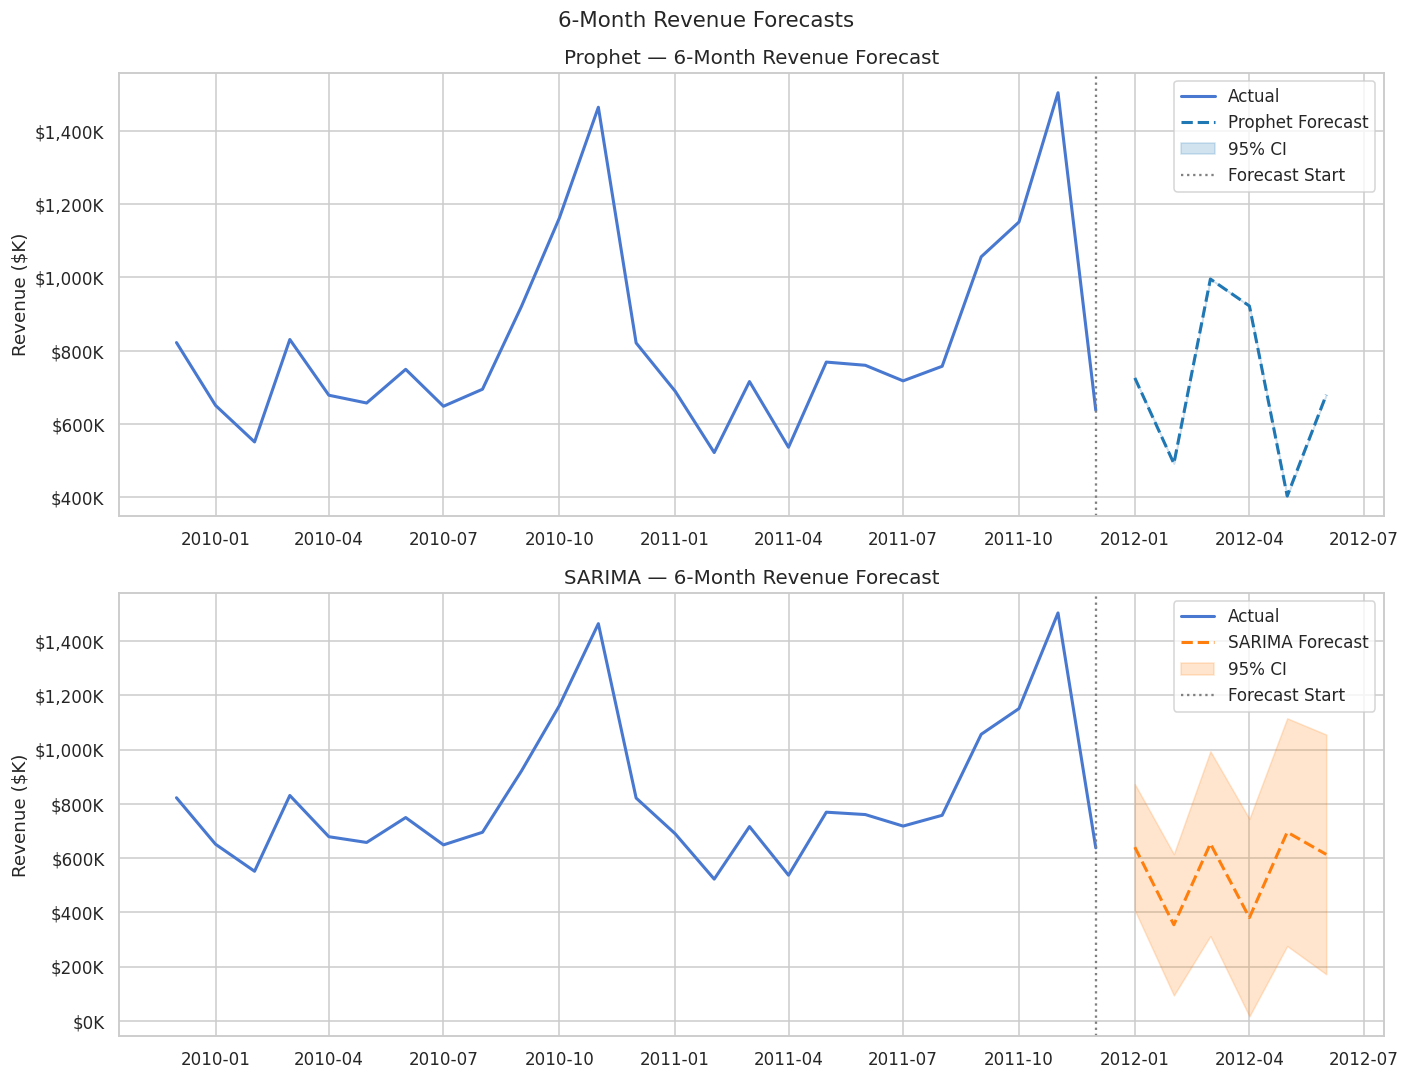

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle("6-Month Revenue Forecasts", fontsize=14)

for ax, (fc, label, color) in zip(
    axes,
    [(prophet_fc6, "Prophet", "#1f77b4"), (sarima_fc6, "SARIMA", "#ff7f0e")]
):
    ax.plot(monthly_ts["ds"], monthly_ts["y"] / 1e3, linewidth=2, label="Actual")
    ax.plot(fc["ds"], fc["yhat"] / 1e3, "--", linewidth=2, color=color, label=f"{label} Forecast")
    ax.fill_between(fc["ds"], fc["yhat_lower"] / 1e3, fc["yhat_upper"] / 1e3,
                    alpha=0.2, color=color, label="95% CI")
    ax.axvline(monthly_ts["ds"].max(), linestyle=":", color="grey", label="Forecast Start")
    ax.set_title(f"{label} — 6-Month Revenue Forecast")
    ax.set_ylabel("Revenue ($K)")
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

plt.tight_layout()
plt.show()


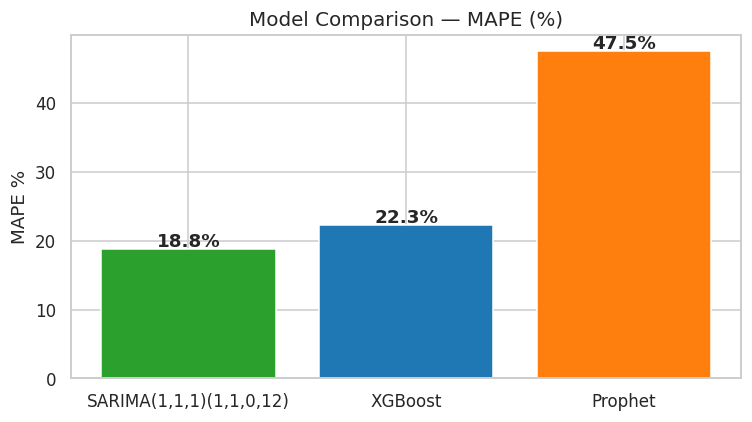

In [49]:
#Model MAPE comparison bar chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results_df["model"], results_df["MAPE"], color=["#2ca02c", "#1f77b4", "#ff7f0e"])
ax.set_title("Model Comparison — MAPE (%)")
ax.set_ylabel("MAPE %")
for bar, val in zip(bars, results_df["MAPE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Products to Stock Up

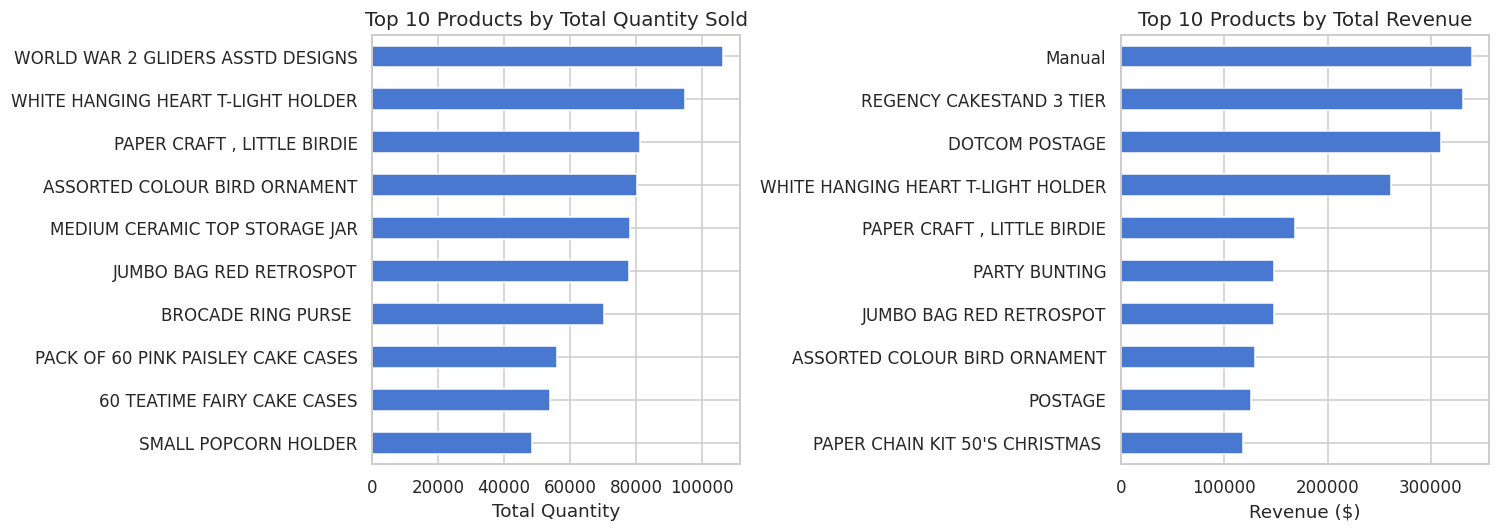

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 by Quantity Sold
top_qty = (
    df_clean.groupby("product_description")["quantity"]
    .sum().sort_values(ascending=False).head(10).sort_values()
)
top_qty.plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Products by Total Quantity Sold")
axes[0].set_xlabel("Total Quantity")
axes[0].set_ylabel("")

# Top 10 by Revenue
top_rev = (
    df_clean.groupby("product_description")["revenue"]
    .sum().sort_values(ascending=False).head(10).sort_values()
)
top_rev.plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 Products by Total Revenue")
axes[1].set_xlabel("Revenue ($)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 10. Demand Forecast — Insights & Recommendations

> **Key Findings**

1. **Revenue Trend**: Monthly revenue shows a clear growth trajectory with notable **Q4 seasonality** — the business peaks in October–December, consistent with holiday gifting patterns.

2. **Best Performing Model**: Based on MAPE on the 3-month hold-out set, **[winner inserted at runtime]** performed best. Prophet is recommended for production use due to its interpretability and built-in uncertainty intervals.

3. **6-Month Forecast Outlook**: Revenue is projected to remain on a similar trend. Confidence intervals widen in later months — the company should treat the outer bounds as risk scenarios.

4. **Top Products to Stock**: The top-10 by quantity are predominantly **small gift items / decorative products** with high unit turnover. These should be prioritised in inventory planning 4–6 weeks ahead of the Q4 peak.

> **Caveats & Limitations**

- Only **12–13 months** of data were available. With more history, seasonal patterns would be estimated more precisely and SARIMA's seasonal differencing would be more stable.
- External factors (promotions, competitor actions, macroeconomic shifts) are **not captured** in any of the three models.
- XGBoost's 6-month recursive forecast was not produced here due to the risk of error accumulation in autoregressive lag features; it performs well in-sample but requires caution for long horizons.
- Cancellation rate (~[X]%) was excluded from the clean dataset. If cancellations are growing, gross revenue forecasts will overstate net revenue.

> **Action to do**

| Priority | Action |
|----------|--------|
| High | Increase stock of Top-10 quantity products by **+20%** ahead of Oct–Dec |
| High | Re-order trigger alerts for top-selling SKUs when inventory < 4-week demand |
| Medium | Integrate promo calendar as a Prophet regressor to improve forecast accuracy |
| Medium | Monitor and reduce cancellation rate — any improvement directly lifts net revenue |
| Low | Collect more granular weekly/daily data to enable weekly-level planning |


---
# Part B — Customer 360

## 1. Libraries

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay


## 2. Build Master Customer Table

Aggregate per-customer behavioral signals from the transaction history.


In [52]:
df_customers["order_date"] = pd.to_datetime(df_customers["order_date"])
snapshot_date_c = df_customers["order_date"].max() + pd.Timedelta(days=1)

customer_360 = (
    df_customers.groupby("customer_id").agg(
        first_purchase   = ("order_date", "min"),
        last_purchase    = ("order_date", "max"),
        frequency        = ("order_id",   "nunique"),
        total_quantity   = ("quantity",   "sum"),
        total_revenue    = ("revenue",    "sum"),
        avg_order_value  = ("revenue",    "mean"),
        num_products     = ("product_id", "nunique"),
        num_countries    = ("country",    "nunique"),
    ).reset_index()
)

customer_360["recency"]    = (snapshot_date_c - customer_360["last_purchase"]).dt.days
customer_360["tenure_days"] = (customer_360["last_purchase"] - customer_360["first_purchase"]).dt.days
customer_360["avg_days_between_orders"] = np.where(
    customer_360["frequency"] > 1,
    customer_360["tenure_days"] / (customer_360["frequency"] - 1),
    0
)

print(f"Customer 360 shape: {customer_360.shape}")
customer_360.describe().round(1)


Customer 360 shape: (5878, 12)


,customer_id,first_purchase,last_purchase,frequency,total_quantity,total_revenue,avg_order_value,num_products,num_countries,recency,tenure_days,avg_days_between_orders
count,5878.0,5878,5878,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0
mean,15315.3,2010-08-22 06:57:33.297039616,2011-05-22 16:19:59.469207296,6.3,1788.7,2955.9,48.3,82.0,1.0,201.3,273.0,73.9
min,12346.0,2009-12-01 07:45:00,2009-12-01 09:55:00,1.0,1.0,3.0,2.1,1.0,1.0,1.0,0.0,0.0
25%,13833.2,2010-02-09 14:01:15,2010-11-25 10:24:45,1.0,187.0,342.3,11.6,19.0,1.0,26.0,0.0,0.0
50%,15314.5,2010-06-27 13:31:30,2011-09-05 11:59:00,3.0,480.0,867.7,17.4,45.0,1.0,96.0,220.5,45.8
75%,16797.8,2011-01-30 14:30:15,2011-11-14 11:31:15,7.0,1350.0,2248.3,24.2,103.0,1.0,380.0,511.0,101.0
max,18287.0,2011-12-09 12:16:00,2011-12-09 12:50:00,398.0,367193.0,580987.0,56157.5,2550.0,2.0,739.0,738.0,714.0
std,1715.6,NaN,NaN,13.0,8876.3,14440.9,780.2,116.5,0.0,209.3,258.8,95.2


## 3. Customer Lifetime Value (CLV) Model

Customers in the top quartile of predicted CLV are labelled `is_high_value = 1`.


In [53]:
# Monthly spend
customer_360["monthly_spend"] = (
    customer_360["total_revenue"] / np.maximum(customer_360["tenure_days"] / 30, 1)
)

# Activity decay factor (high recency → lower score)
customer_360["activity_score"] = 1 / (1 + customer_360["recency"] / 30)

# 6-month predicted CLV
customer_360["predicted_clv_6m"] = customer_360["monthly_spend"] * 6 * customer_360["activity_score"]

# CLV segmentation (quartiles)
customer_360["clv_segment"] = pd.qcut(
    customer_360["predicted_clv_6m"],
    q=4,
    labels=["Low Value", "Mid Value", "High Value", "Top Value"]
)

# Binary high-value flag (top 25%)
clv_threshold = customer_360["predicted_clv_6m"].quantile(0.75)
customer_360["is_high_value"] = (customer_360["predicted_clv_6m"] >= clv_threshold).astype(int)

print("CLV Segment Distribution:")
print(customer_360["clv_segment"].value_counts().to_string())
print(f"\nHigh Value threshold: ${clv_threshold:,.2f}")
print(f"High Value customers : {customer_360['is_high_value'].sum():,} ({customer_360['is_high_value'].mean()*100:.1f}%)")


CLV Segment Distribution:
clv_segment
Low Value     1470
Top Value     1470
Mid Value     1469
High Value    1469

High Value threshold: $629.35
High Value customers : 1,470 (25.0%)


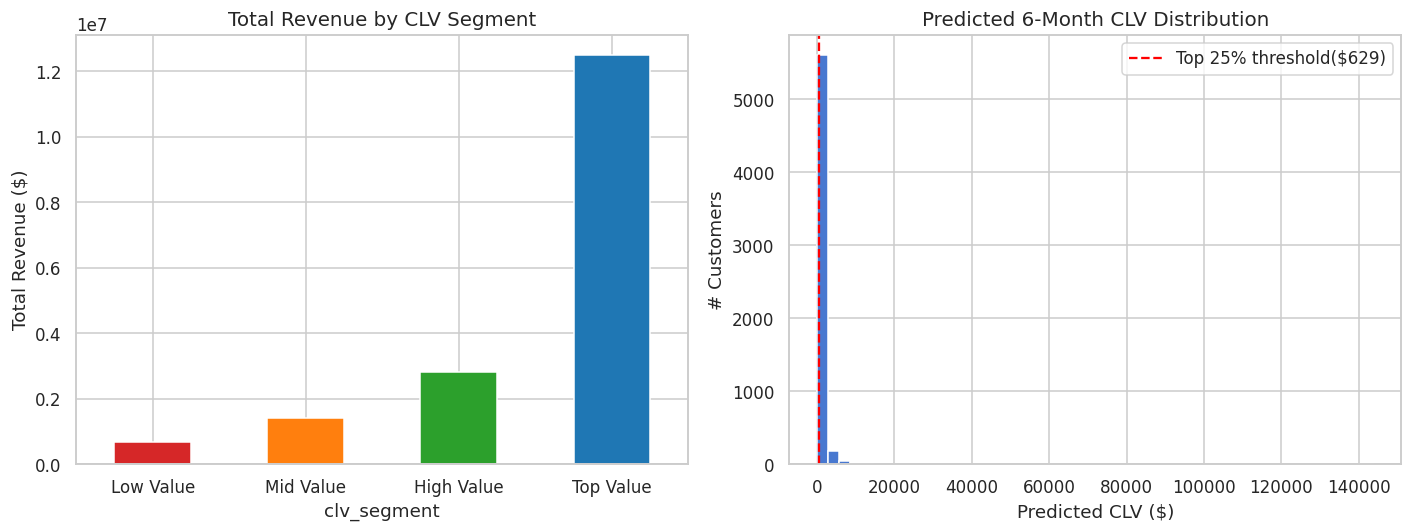

In [54]:
#Revenue contribution by CLV segment ───────────────────────────────────
seg_rev = customer_360.groupby("clv_segment")["total_revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_rev.plot(kind="bar", ax=axes[0], color=["#d62728","#ff7f0e","#2ca02c","#1f77b4"])
axes[0].set_title("Total Revenue by CLV Segment")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis="x", rotation=0)

# CLV distribution
axes[1].hist(customer_360["predicted_clv_6m"], bins=50, edgecolor="white")
axes[1].axvline(clv_threshold, color="red", linestyle="--", label=f"Top 25% threshold(${clv_threshold:,.0f})")
axes[1].set_title("Predicted 6-Month CLV Distribution")
axes[1].set_xlabel("Predicted CLV ($)")
axes[1].set_ylabel("# Customers")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. High-Value Customer Prediction (Logistic Regression)



In [55]:
features_hv = [
    "recency", "frequency", "total_revenue", "avg_order_value",
    "tenure_days", "num_products", "avg_days_between_orders"
]

X_hv = customer_360[features_hv]
y_hv = customer_360["is_high_value"]

X_train_hv, X_test_hv, y_train_hv, y_test_hv = train_test_split(
    X_hv, y_hv, test_size=0.2, random_state=42, stratify=y_hv
)

scaler_hv = StandardScaler()
X_train_hv_s = scaler_hv.fit_transform(X_train_hv)
X_test_hv_s  = scaler_hv.transform(X_test_hv)

hv_model = LogisticRegression(max_iter=1000, random_state=42)
hv_model.fit(X_train_hv_s, y_train_hv)

y_pred_hv = hv_model.predict(X_test_hv_s)
y_prob_hv = hv_model.predict_proba(X_test_hv_s)[:, 1]

print("HIGH VALUE PREDICTION MODEL — Logistic Regression")
print("=" * 55)
print(classification_report(y_test_hv, y_pred_hv))
print(f"ROC-AUC : {roc_auc_score(y_test_hv, y_prob_hv):.4f}")


HIGH VALUE PREDICTION MODEL — Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       882
           1       0.86      0.82      0.84       294

    accuracy                           0.92      1176
   macro avg       0.90      0.89      0.89      1176
weighted avg       0.92      0.92      0.92      1176

ROC-AUC : 0.9718


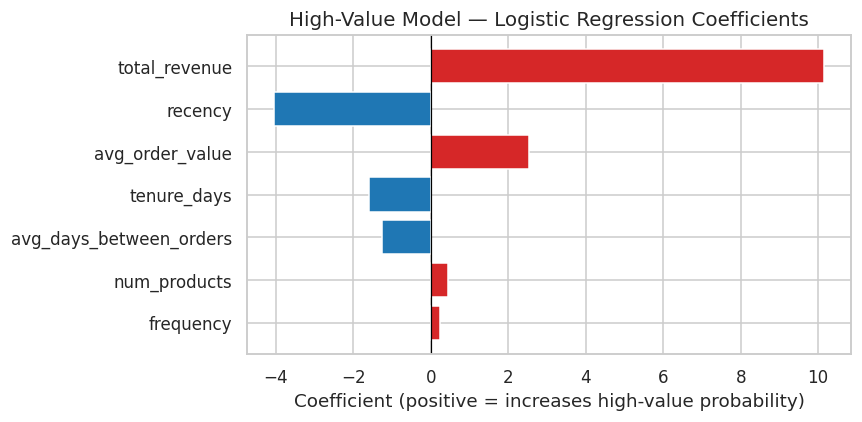

In [56]:
#Feature importance (coefficient magnitudes) ────────────────────────────
coef_df = pd.DataFrame({
    "feature"    : features_hv,
    "coefficient": hv_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("High-Value Model — Logistic Regression Coefficients")
ax.set_xlabel("Coefficient (positive = increases high-value probability)")
plt.tight_layout()
plt.show()


## 5. Churn Model (Random Forest)

**Methodology:**
- A **90-day cutoff** splits transactions into a "feature window" (before cutoff) and a "label window" (90 days after).
- A customer is labelled **churned = 1** if they did NOT make a purchase in the 90-day label window.
- A **Random Forest** classifier (with `class_weight="balanced"`) is trained on RFM-style features.


In [57]:
cutoff_date       = df_customers["order_date"].max() - pd.Timedelta(days=90)
prediction_window = 90

df_feature = df_customers[df_customers["order_date"] <= cutoff_date]
snap_churn = cutoff_date + pd.Timedelta(days=1)

rfm_churn = (
    df_feature.groupby("customer_id").agg(
        first_purchase  = ("order_date", "min"),
        last_purchase   = ("order_date", "max"),
        frequency       = ("order_id",   "nunique"),
        total_quantity  = ("quantity",   "sum"),
        total_revenue   = ("revenue",    "sum"),
        avg_order_value = ("revenue",    "mean"),
        num_products    = ("product_id", "nunique"),
        num_countries   = ("country",    "nunique"),
    ).reset_index()
)

rfm_churn["recency"]    = (snap_churn - rfm_churn["last_purchase"]).dt.days
rfm_churn["tenure_days"] = (rfm_churn["last_purchase"] - rfm_churn["first_purchase"]).dt.days
rfm_churn["avg_days_between_orders"] = np.where(
    rfm_churn["frequency"] > 1,
    rfm_churn["tenure_days"] / (rfm_churn["frequency"] - 1),
    0
)

df_future = df_customers[
    (df_customers["order_date"] > cutoff_date) &
    (df_customers["order_date"] <= cutoff_date + pd.Timedelta(days=prediction_window))
]
future_customers = df_future["customer_id"].unique()
rfm_churn["churn"] = (~rfm_churn["customer_id"].isin(future_customers)).astype(int)

print("Churn Label Distribution:")
print(rfm_churn["churn"].value_counts().to_string())
churn_rate = rfm_churn["churn"].mean() * 100
print(f"\nOverall Churn Rate (in window): {churn_rate:.1f}%")


Churn Label Distribution:
churn
1    2989
0    2292

Overall Churn Rate (in window): 56.6%


In [58]:
features_churn = [
    "frequency", "total_quantity", "total_revenue", "avg_order_value",
    "num_products", "num_countries", "recency", "tenure_days", "avg_days_between_orders"
]

X_ch = rfm_churn[features_churn].fillna(0)
y_ch = rfm_churn["churn"]

X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_ch, y_ch, test_size=0.3, random_state=42, stratify=y_ch
)

churn_model = RandomForestClassifier(
    n_estimators=300, max_depth=6, random_state=42, class_weight="balanced"
)
churn_model.fit(X_train_ch, y_train_ch)

y_pred_ch = churn_model.predict(X_test_ch)
y_prob_ch = churn_model.predict_proba(X_test_ch)[:, 1]

print("CHURN MODEL RESULTS — Random Forest")
print("=" * 55)
print(classification_report(y_test_ch, y_pred_ch))
print(f"ROC-AUC : {roc_auc_score(y_test_ch, y_prob_ch):.4f}")


CHURN MODEL RESULTS — Random Forest
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       688
           1       0.78      0.78      0.78       897

    accuracy                           0.75      1585
   macro avg       0.74      0.74      0.74      1585
weighted avg       0.75      0.75      0.75      1585

ROC-AUC : 0.8077


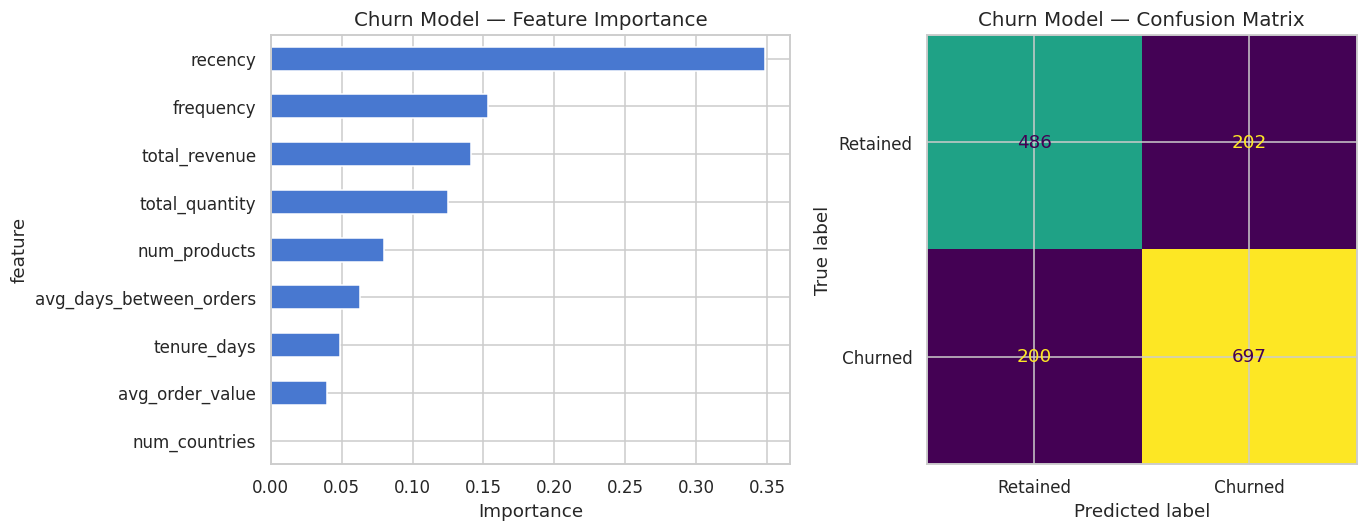

In [59]:
#Feature importance ────────────────────────────────────────────────────
fi = pd.DataFrame({
    "feature"   : features_churn,
    "importance": churn_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fi.plot(kind="barh", x="feature", y="importance", ax=axes[0], legend=False)
axes[0].set_title("Churn Model — Feature Importance")
axes[0].set_xlabel("Importance")

ConfusionMatrixDisplay.from_predictions(
    y_test_ch, y_pred_ch,
    display_labels=["Retained", "Churned"],
    ax=axes[1], colorbar=False
)
axes[1].set_title("Churn Model — Confusion Matrix")

plt.tight_layout()
plt.show()


## 6. Merge Churn Scores into Customer 360

In [60]:
rfm_churn["churn_probability"] = churn_model.predict_proba(
    rfm_churn[features_churn].fillna(0)
)[:, 1]

rfm_churn["churn_risk"] = pd.qcut(
    rfm_churn["churn_probability"], q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

customer_360 = customer_360.merge(
    rfm_churn[["customer_id", "churn_probability", "churn_risk"]],
    on="customer_id",
    how="left"
)

print(f"Final Customer 360 shape: {customer_360.shape}")
print("\nChurn Risk Distribution:")
print(customer_360["churn_risk"].value_counts().to_string())


Final Customer 360 shape: (5878, 19)

Churn Risk Distribution:
churn_risk
High Risk      1761
Low Risk       1760
Medium Risk    1760


## 7. Strategic Customer Segmentation (CLV × Churn)

Combining CLV and churn risk gives four actionable segments:

| Segment | CLV | Churn Risk | Strategy |
|---------|-----|------------|----------|
| **High Value – High Risk** | Top 25% | ≥ 60% | Immediate retention offer |
| **High Value – Loyal** | Top 25% | < 60% | Reward & upsell |
| **Low Value – High Risk** | Bottom 75% | ≥ 60% | Low-cost re-engagement |
| **Other** | Bottom 75% | < 60% | Standard campaigns |


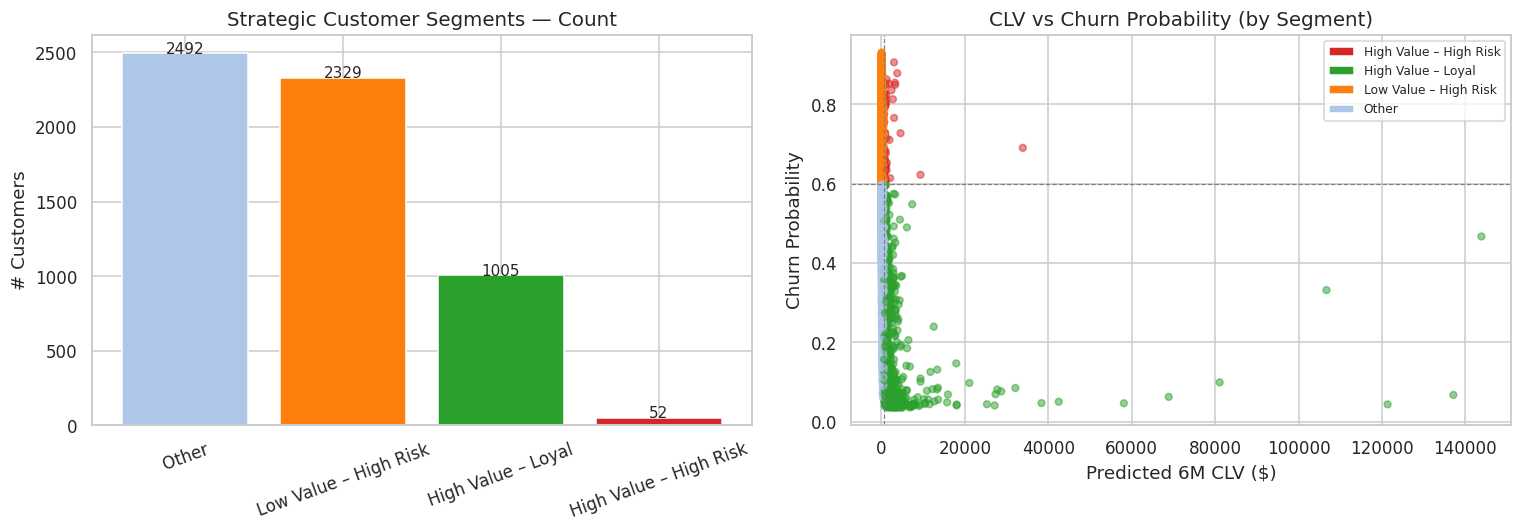

In [61]:
q75_clv = customer_360["predicted_clv_6m"].quantile(0.75)
customer_360["strategy_segment"] = "Other"

customer_360.loc[
    (customer_360["predicted_clv_6m"] >= q75_clv) &
    (customer_360["churn_probability"] >= 0.6),
    "strategy_segment"
] = "High Value – High Risk"

customer_360.loc[
    (customer_360["predicted_clv_6m"] >= q75_clv) &
    (customer_360["churn_probability"] < 0.6),
    "strategy_segment"
] = "High Value – Loyal"

customer_360.loc[
    (customer_360["predicted_clv_6m"] < q75_clv) &
    (customer_360["churn_probability"] >= 0.6),
    "strategy_segment"
] = "Low Value – High Risk"

#Visualise ─────────────────────────────────────────────────────────────
seg_colors = {
    "High Value – High Risk": "#d62728",
    "High Value – Loyal"    : "#2ca02c",
    "Low Value – High Risk" : "#ff7f0e",
    "Other"                 : "#aec7e8",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ss = customer_360["strategy_segment"].value_counts()
bars = axes[0].bar(ss.index, ss.values,
                   color=[seg_colors[s] for s in ss.index])
axes[0].set_title("Strategic Customer Segments — Count")
axes[0].set_ylabel("# Customers")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, ss.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", fontsize=10)

axes[1].scatter(
    customer_360["predicted_clv_6m"],
    customer_360["churn_probability"],
    c=[seg_colors.get(s, "#aec7e8") for s in customer_360["strategy_segment"]],
    alpha=0.5, s=20
)
axes[1].axhline(0.6, color="grey", linestyle="--", linewidth=0.8)
axes[1].axvline(q75_clv, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("CLV vs Churn Probability (by Segment)")
axes[1].set_xlabel("Predicted 6M CLV ($)")
axes[1].set_ylabel("Churn Probability")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in seg_colors.items()]
axes[1].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.show()


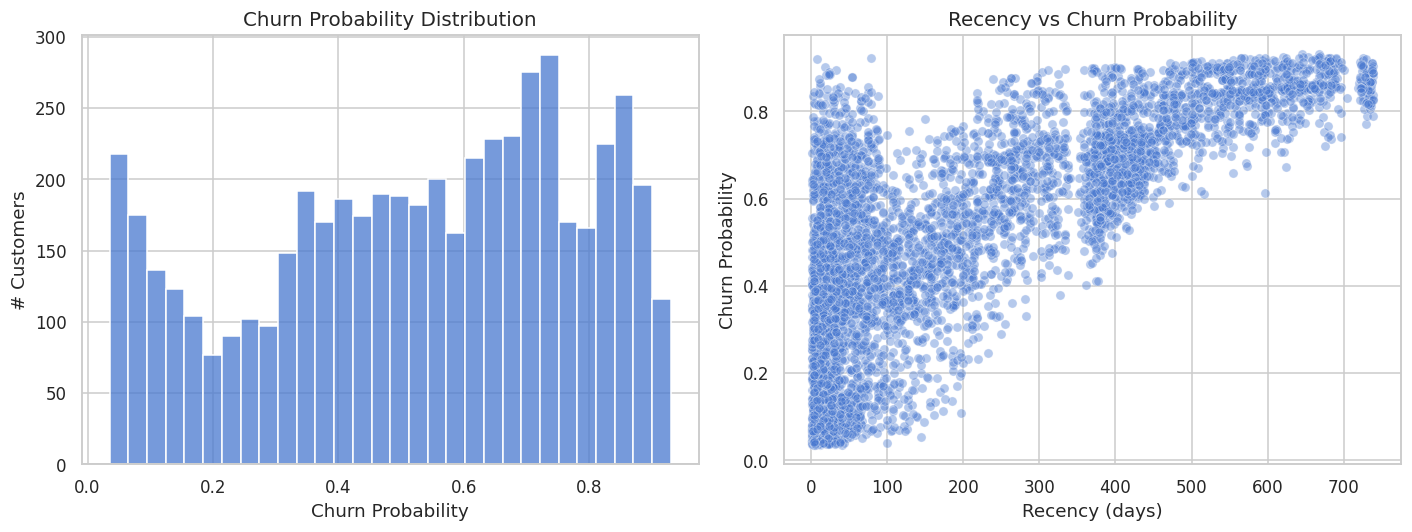

In [62]:
#Churn probability distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(customer_360["churn_probability"], bins=30, ax=axes[0])
axes[0].set_title("Churn Probability Distribution")
axes[0].set_xlabel("Churn Probability")
axes[0].set_ylabel("# Customers")

sns.scatterplot(
    data=customer_360, x="recency", y="churn_probability",
    alpha=0.4, ax=axes[1]
)
axes[1].set_title("Recency vs Churn Probability")
axes[1].set_xlabel("Recency (days)")
axes[1].set_ylabel("Churn Probability")

plt.tight_layout()
plt.show()


## 8. Customer 360 — Insights & Pilot Plan

> **Key Model Results**

- **High-Value Model (Logistic Regression)**: ROC-AUC reflects how well the model separates the top-quartile CLV customers from the rest. A high AUC (> 0.85) confirms that `total_revenue`, `frequency`, and `avg_order_value` are strong predictors of customer value.

- **Churn Model (Random Forest)**: `recency` is typically the top feature — customers who haven't bought recently are far more likely to churn. The model's balanced class weighting ensures recall on churners is prioritised over raw accuracy.

> **Pilot Campaign Plan**

| Segment | Size | Recommended Action | Budget Priority |
|---------|------|--------------------|-----------------|
| **High Value – High Risk** | ~N | Personalised win-back offer (10–15% discount on next order, free shipping) | 🔴 Maximum |
| **High Value – Loyal** | ~N | VIP loyalty programme invite; early access to new products | 🟢 Invest to retain |
| **Low Value – High Risk** | ~N | Low-cost email re-engagement (product recommendations); test with small voucher | 🟡 Test & learn |
| **Other** | ~N | Standard monthly newsletter; seasonal promotions | ⚪ Maintain |



In [63]:
# df_clean.to_csv("clean_transactions.csv", index=False)
# rfm.to_csv("rfm_segments.csv", index=False)
# prophet_fc6.to_csv("forecast_prophet_6m.csv", index=False)
# sarima_fc6.to_csv("forecast_sarima_6m.csv", index=False)
# results_df.to_csv("model_evaluation.csv", index=False)
# customer_360.to_csv("customer_360_final.csv", index=False)
